C:\Users\Reinier.vandenAkker\AppData\Local\Temp\ipykernel_39788\3201685333.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stocks = yf.download("AAPL", period='15y')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2010-11-15,9.208452,9.313421,9.185359,9.251040,403606000
2010-11-16,9.044992,9.225238,8.976912,9.168855,657650000
2010-11-17,9.012307,9.116975,8.930131,9.033301,479449600
2010-11-18,9.250138,9.287327,9.137972,9.153267,494491200
2010-11-19,9.199150,9.249235,9.154464,9.236339,384843200
...,...,...,...,...,...
2025-11-07,268.209991,272.026299,266.511626,269.538690,48227400
2025-11-10,269.429993,273.730011,267.459991,268.959991,41312400
2025-11-11,275.250000,275.910004,269.799988,269.809998,46208300


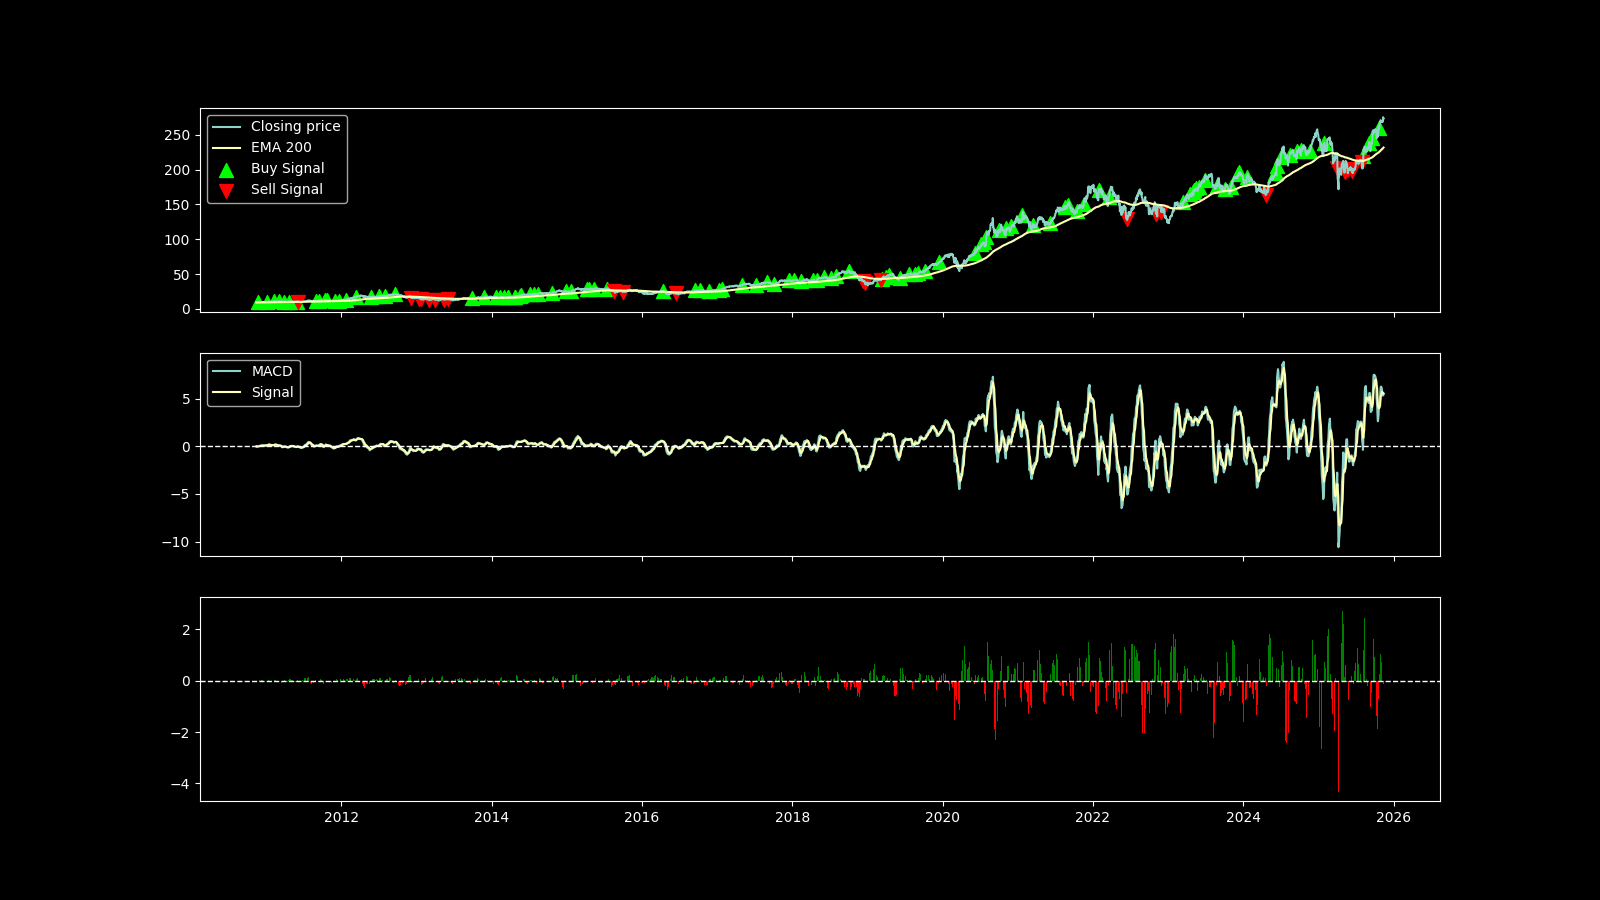

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
%matplotlib widget


plt.style.use("dark_background")

short_window = 12
long_window = 26
signal_window = 9


#fetch stock data
stocks = yf.download("AAPL", period='15y')

df = pd.DataFrame(stocks)
df.columns = df.columns.droplevel(1)

display(df)

#calculate EMAs and MACDs
df['EMA12'] = df['Close'].ewm(span = short_window, adjust = False).mean()
df['EMA26'] = df['Close'].ewm(span = long_window, adjust = False).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal'] = df['MACD'].ewm(span=signal_window, adjust=False).mean()
df['hist_difference'] = df['MACD'] - df['Signal']
df['EMA200'] = df['Close'].ewm(span = 200, adjust = False).mean()
df['Trend_direction'] = np.where(df['Close'] > df['EMA200'], 'up', 'down')

# detect MACD crossovers: buy = MACD crosses above Signal
df['Buy_Signal'] = (df['MACD'].shift(1) < df['Signal'].shift(1)) & (df['MACD'] > df['Signal'])

# SELL = MACD kruist onder signal
df['Sell_Signal'] = (df['MACD'].shift(1) > df['Signal'].shift(1)) & (df['MACD'] < df['Signal'])
df['Buy_Signal']  = df['Buy_Signal']  & (df['Close'] > df['EMA200'])
df['Sell_Signal'] = df['Sell_Signal'] & (df['Close'] < df['EMA200'])



#plotting figures
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(16,9))

#Top plot
ax1.plot(df.index, df['Close'], label='Closing price')
ax1.plot(df.index, df['EMA200'], label='EMA 200')

# plot buy markers (groene driehoekjes)
# koopmomenten
ax1.scatter(df.loc[df['Buy_Signal']].index,
            df.loc[df['Buy_Signal'], 'Close'],
            marker='^', color='lime', s=100, label='Buy Signal')

# verkoopmomenten
ax1.scatter(df.loc[df['Sell_Signal']].index,
            df.loc[df['Sell_Signal'], 'Close'],
            marker='v', color='red', s=100, label='Sell Signal')

ax1.legend()



#Middle plot
ax2.plot(df['MACD'], label='MACD')
ax2.plot(df['Signal'], label='Signal')
ax2.legend()
ax2.axhline(0, color='white', linestyle='--', linewidth=1)

#bottom plot
ax3.plot()
ax3.bar(df.index, df['hist_difference'], color=['green' if h >= 0 else 'red' for h in df['hist_difference']], width=1)
ax3.axhline(0, color='white', linestyle='--', linewidth=1)



plt.show()

,Buy & Hold,MACD Strategy
Total Return,28.666832,12.575612
CAGR,0.253475,0.189843
Volatility (ann),0.282718,0.237167
Sharpe Ratio,0.942718,0.853566
Max Drawdown,-0.437972,-0.314272
Win Rate,NaN,0.875000
Average Win,NaN,0.535927
Average Loss,NaN,-0.124497


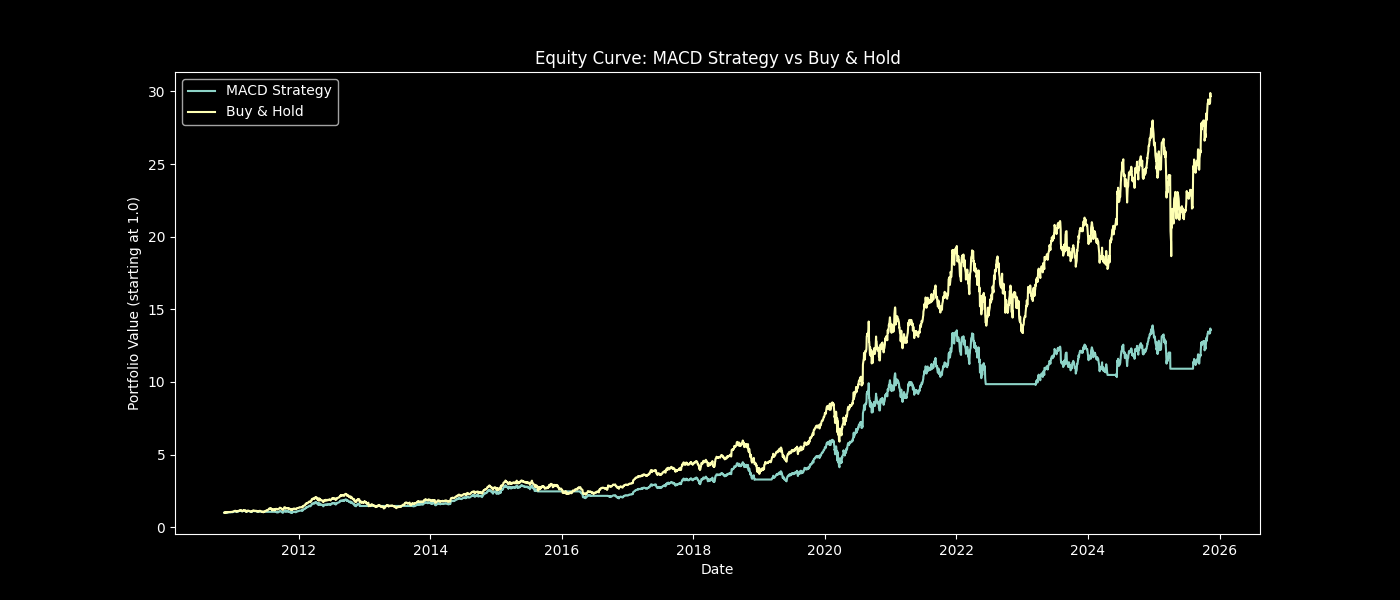

In [ ]:


equity = 1.0                           # portfolio start at 1.0
macd_equity_daily = []                 # daily updated equity curve
in_position = False
entry_price = None
trade_returns = []                     # percentage returns per completed trade

# Run daily backtest
for date, row in df.iterrows():

    # --- ENTRY ---
    if row['Buy_Signal'] and not in_position:
        in_position = True
        entry_price = row['Close']

    # --- EXIT ---
    elif row['Sell_Signal'] and in_position:
        in_position = False
        exit_price = row['Close']

        # return of this trade (factor form)
        trade_return = exit_price / entry_price
        trade_returns.append(trade_return - 1)

        # update portfolio equity value
        equity *= trade_return

    # --- DAILY MARKET-TO-MARKET ---
    if in_position:
        # unrealized PnL: portfolio moves with price relative to entry
        equity_today = equity * (row['Close'] / entry_price)
    else:
        equity_today = equity

    macd_equity_daily.append(equity_today)

# convert daily equity list → Series
macd_equity_curve = pd.Series(macd_equity_daily, index=df.index)


# BUY & HOLD STRATEGY
HODL_strat = df['Close'] / df['Close'].iloc[0]



# DAILY RETURNS
bh_daily = HODL_strat.pct_change().dropna()
macd_daily = macd_equity_curve.pct_change().dropna()



# ANNUALIZED RETURN

years = (df.index[-1] - df.index[0]).days / 365

cagr_bh = (HODL_strat.iloc[-1]) ** (1 / years) - 1
cagr_macd = (macd_equity_curve.iloc[-1]) ** (1 / years) - 1



# TOTAL RETURN
total_return_bh = HODL_strat.iloc[-1] - 1
total_return_macd = macd_equity_curve.iloc[-1] - 1



# VOLATILITY (annualized)
vol_bh = bh_daily.std() * np.sqrt(252)
vol_macd = macd_daily.std() * np.sqrt(252)



# SHARPE RATIO
sharpe_bh = (bh_daily.mean() * 252) / vol_bh
sharpe_macd = (macd_daily.mean() * 252) / vol_macd



# MAX DRAWDOWN
def max_drawdown(series):
    peak = series.cummax()
    dd = (series - peak) / peak
    return dd.min()

max_dd_bh = max_drawdown(HODL_strat)
max_dd_macd = max_drawdown(macd_equity_curve)



# WIN RATE + AVERAGE WINS/LOSSES (MACD ONLY)
trade_returns_series = pd.Series(trade_returns)

win_rate = np.mean(trade_returns_series > 0)

avg_win = trade_returns_series[trade_returns_series > 0].mean()
avg_loss = trade_returns_series[trade_returns_series < 0].mean()



# METRICS TABLE
metrics = pd.DataFrame({
    'Buy & Hold': [
        total_return_bh,
        cagr_bh,
        vol_bh,
        sharpe_bh,
        max_dd_bh,
        np.nan,
        np.nan,
        np.nan
    ],
    'MACD Strategy': [
        total_return_macd,
        cagr_macd,
        vol_macd,
        sharpe_macd,
        max_dd_macd,
        win_rate,
        avg_win,
        avg_loss
    ]
}, index=[
    'Total Return',
    'CAGR',
    'Volatility (ann)',
    'Sharpe Ratio',
    'Max Drawdown',
    'Win Rate',
    'Average Win',
    'Average Loss'
])

display(metrics)



# PLOT EQUITY CURVES

plt.figure(figsize=(14,6))
plt.plot(macd_equity_curve, label='MACD Strategy')
plt.plot(HODL_strat, label='Buy & Hold')
plt.title("Equity Curve: MACD Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (starting at 1.0)")
plt.legend()
plt.show()
